In [1]:
"""
Side effects of importing `notebook_bootstrap`:

When this module is imported, it performs the following actions immediately:

1. Determines the directory where this file (`notebook_add_path.py`) resides.
   This directory is assumed to be `Python_src/Notebooks/`.

2. Computes the parent directory of that location, assumed to be the project
   source directory (`Python_src/`).

3. Prepends that project source directory to `sys.path`, if it is not already
   present.

As a result, Jupyter notebooks located inside `Python_src/Notebooks/` can
import project modules under development using standard import statements, e.g.:

    from image_viewer_app import launch_image_viewer

Scope and limitations:
- The modification of `sys.path` is temporary and applies only to the current
  Python interpreter / Jupyter kernel.
- No environment variables (such as PYTHONPATH) are modified.
- No changes persist after the kernel is restarted.
- This module is intended for interactive development and debugging only.

This import should be removed once the project is packaged and installed
properly (e.g. via `pip install -e .`).
"""

import notebook_add_path


[notebook_bootstrap] Added to sys.path: C:\user\AQ_SCC\72_OM4M008_LENSPMD25_CPU_GPU_FPA\Python_src


In [2]:
"""
Matplotlib backend setup (must run first).

Configures the matplotlib backend for inline rendering.
Must be executed before importing matplotlib.pyplot (directly or indirectly),
otherwise the backend is locked and this setting has no effect.

Imports for the FPA image processing and timining (the partial)
"""
%matplotlib inline
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
print(matplotlib.get_backend())

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from image_viewer_app import launch_image_viewer

module://matplotlib_inline.backend_inline


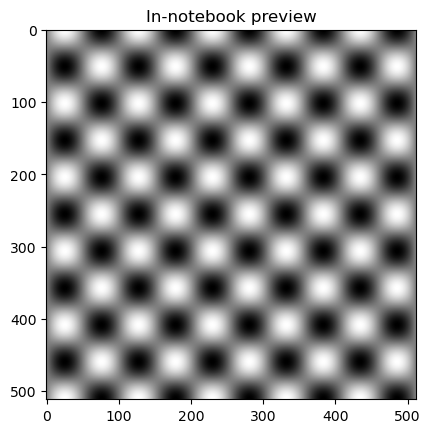

In [3]:
# Example: synthetic test image
x = np.linspace(0, 1, 512)
y = np.linspace(0, 1, 512)
X, Y = np.meshgrid(x, y)
img = np.sin(10 * np.pi * X) * np.cos(10 * np.pi * Y)

# Show in notebook just to check (optional)
plt.imshow(img, cmap="gray")
plt.title("In-notebook preview")
plt.show()

# Launch external viewer (non-blocking, own process)
launch_image_viewer(img, title="Hilbert test pattern 1")
launch_image_viewer(np.log(2+img), title="Hilbert test pattern 2")


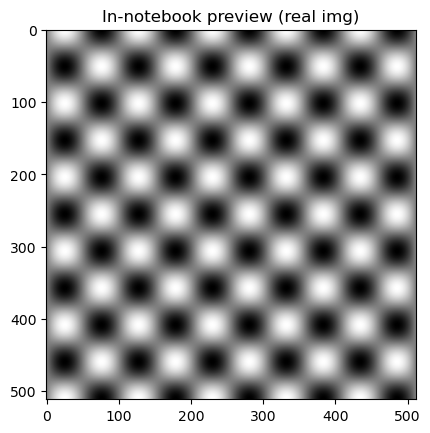

In [4]:
# --- Example: synthetic test image (real) ---
x = np.linspace(0, 1, 512)
y = np.linspace(0, 1, 512)
X, Y = np.meshgrid(x, y)
img = np.sin(10 * np.pi * X) * np.cos(10 * np.pi * Y)

# In-notebook preview (optional)
plt.imshow(img, cmap="gray")
plt.title("In-notebook preview (real img)")
plt.show()

# --- Build a complex TensorFlow "image" ---
# Use the real img as amplitude, and create a smooth phase ramp
img_tf = tf.convert_to_tensor(img, dtype=tf.float32)

phase_tf = 2.0 * np.pi * tf.convert_to_tensor(X, dtype=tf.float32) + 0.5 * np.pi * tf.convert_to_tensor(Y, dtype=tf.float32)

# complex image: z = img * exp(j*phase)
z_tf = tf.cast(img_tf, tf.complex64) * tf.exp(1j * tf.cast(phase_tf, tf.complex64))

# --- Compute magnitude and phase (TensorFlow) ---
mag_tf = tf.abs(z_tf)
ph_tf  = tf.math.angle(z_tf)   # phase in [-pi, pi]

# Convert to NumPy for the viewer process
mag = mag_tf.numpy()
ph  = ph_tf.numpy()

# --- Launch external viewers (non-blocking, separate process) ---
launch_image_viewer(mag, title="TF complex image |z| (magnitude)")
launch_image_viewer(ph,  title="TF complex image ∠z (phase)")


In [5]:
print(matplotlib.get_backend())

module://matplotlib_inline.backend_inline
